In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [4]:
loan_data = pd.read_csv("data/loan_data.csv")
loan_data

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45337,45338,Fully Paid,8000,36 months,72000,18.97,4.57850,9725,58.2,credit_card,...,1,0,9,4.2,paid off,8,credit_card,RENT,> 1 Year,0.35
45338,45339,Fully Paid,2000,36 months,25200,13.24,3.20333,4925,40.7,wedding,...,0,1,13,4.2,paid off,3,other,MORTGAGE,> 1 Year,0.50
45339,45340,Fully Paid,4375,36 months,20000,7.95,9.98460,6574,73.0,debt_consolidation,...,1,1,8,2.4,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.55
45340,45341,Fully Paid,8000,36 months,48000,26.91,6.45250,10303,32.4,debt_consolidation,...,1,1,10,5.2,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.65


In [5]:
loan_data.outcome.value_counts()

outcome
default     22671
paid off    22671
Name: count, dtype: int64

In [6]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         45342 non-null  int64  
 1   status             45342 non-null  object 
 2   loan_amnt          45342 non-null  int64  
 3   term               45342 non-null  object 
 4   annual_inc         45342 non-null  int64  
 5   dti                45342 non-null  float64
 6   payment_inc_ratio  45342 non-null  float64
 7   revol_bal          45342 non-null  int64  
 8   revol_util         45342 non-null  float64
 9   purpose            45342 non-null  object 
 10  home_ownership     45342 non-null  object 
 11  delinq_2yrs_zero   45342 non-null  int64  
 12  pub_rec_zero       45342 non-null  int64  
 13  open_acc           45342 non-null  int64  
 14  grade              45342 non-null  float64
 15  outcome            45342 non-null  object 
 16  emp_length         453

In [7]:
loan_data.outcome = loan_data.outcome.astype('category')
loan_data.outcome.cat.reorder_categories(['paid off', 'default'])
loan_data.purpose_ = loan_data.purpose_.astype('category')
loan_data.home_ = loan_data.home_.astype('category')
loan_data.emp_len_ = loan_data.emp_len_.astype('category')

In [8]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Unnamed: 0         45342 non-null  int64   
 1   status             45342 non-null  object  
 2   loan_amnt          45342 non-null  int64   
 3   term               45342 non-null  object  
 4   annual_inc         45342 non-null  int64   
 5   dti                45342 non-null  float64 
 6   payment_inc_ratio  45342 non-null  float64 
 7   revol_bal          45342 non-null  int64   
 8   revol_util         45342 non-null  float64 
 9   purpose            45342 non-null  object  
 10  home_ownership     45342 non-null  object  
 11  delinq_2yrs_zero   45342 non-null  int64   
 12  pub_rec_zero       45342 non-null  int64   
 13  open_acc           45342 non-null  int64   
 14  grade              45342 non-null  float64 
 15  outcome            45342 non-null  category
 16  emp_

In [9]:
predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], prefix="", prefix_sep="")
y = loan_data[outcome]

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model.fit(X_train, y_train)

,alpha,0.01
,force_alpha,True
,fit_prior,True
,class_prior,None


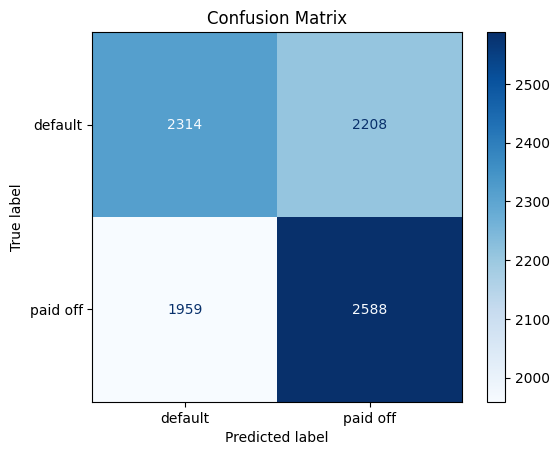

In [10]:
y_test_pred = pd.DataFrame({"outcome":naive_model.predict(X_test),
                            "index1": X_test.index})

y_test = pd.DataFrame({"outcome": y_test.values,
                      "index1": y_test.index})

cm = confusion_matrix(y_test.outcome, y_test_pred.outcome, labels=naive_model.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=naive_model.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [11]:
y_test = pd.DataFrame(y_test)
y_test["outcome_binary"] = [1 if i == "paid off" else 0 for i in y_test.outcome.values]
y_test_pred["outcome_binary"] = [1 if i == "paid off" else 0 for i in y_test_pred.outcome.values]


In [12]:

print(precision_score(y_test.outcome_binary, y_test_pred.outcome_binary ))
print(recall_score(y_test.outcome_binary, y_test_pred.outcome_binary ))
print(accuracy_score(y_test.outcome_binary, y_test_pred.outcome_binary ))

0.5396163469557965
0.5691664833956455
0.5405226596096593


In [13]:
naive_model.predict_proba(X_test)

array([[0.47464442, 0.52535558],
       [0.50322293, 0.49677707],
       [0.53682842, 0.46317158],
       ...,
       [0.5568676 , 0.4431324 ],
       [0.53682842, 0.46317158],
       [0.53682842, 0.46317158]], shape=(9069, 2))

In [14]:
X_test.loc[[19058], :]

,credit_card,debt_consolidation,home_improvement,major_purchase,medical,other,small_business,MORTGAGE,OWN,RENT,< 1 Year,> 1 Year
19058,True,False,False,False,False,False,False,False,False,True,False,True


In [15]:
probabilities = pd.DataFrame(naive_model.predict_proba(X_test.loc[[19058], :]),
columns=loan_data[outcome].cat.categories)

In [16]:
probabilities

,default,paid off
0,0.474644,0.525356


In [17]:
y_test.loc[y_test.index1 == 19058]

,outcome,index1,outcome_binary
0,default,19058,0


In [18]:
y_test_pred.loc[y_test_pred.index1 == 19058]

,outcome,index1,outcome_binary
0,paid off,19058,1


In [19]:
y_test

,outcome,index1,outcome_binary
0,default,19058,0
1,paid off,24360,1
2,paid off,33389,1
3,default,16055,0
4,paid off,40154,1
...,...,...,...
9064,default,4998,0
9065,paid off,29574,1
9066,default,6898,0
9067,paid off,23927,1


In [20]:
y_test_pred

,outcome,index1,outcome_binary
0,paid off,19058,1
1,default,24360,0
2,default,33389,0
3,default,16055,0
4,paid off,40154,1
...,...,...,...
9064,default,4998,0
9065,default,29574,0
9066,default,6898,0
9067,default,23927,0


In [21]:
0.5396163469557965
0.5691664833956455
0.5405226596096593

0.5405226596096593

In [28]:
loan3000 = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/loan3000.csv")
loan3000.head()

,Unnamed: 0,outcome,purpose_,dti,borrower_score,payment_inc_ratio
0,32109,paid off,debt_consolidation,21.23,0.40,5.11135
1,16982,default,credit_card,15.49,0.40,5.43165
2,25335,paid off,debt_consolidation,27.30,0.70,9.23003
3,34580,paid off,major_purchase,21.11,0.40,2.33482
4,14424,default,debt_consolidation,16.46,0.45,12.10320


In [31]:
loan3000.outcome = loan3000.outcome.astype("category")

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = "outcome"

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)

pd.DataFrame(loan_lda.scalings_, index=X.columns)

,0
borrower_score,7.175839
payment_inc_ratio,-0.099676


In [ ]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


In [37]:
loan_lda.scalings_

array([[ 7.1758388 ],
       [-0.09967559]])

In [38]:
loan_lda.means_

array([[0.46280277, 8.86181347],
       [0.53906752, 7.4651989 ]])

In [39]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
lda_df.head()


,Unnamed: 0,outcome,purpose_,dti,borrower_score,payment_inc_ratio,default
0,32109,paid off,debt_consolidation,21.23,0.40,5.11135,0.553544
1,16982,default,credit_card,15.49,0.40,5.43165,0.558953
2,25335,paid off,debt_consolidation,27.30,0.70,9.23003,0.272696
3,34580,paid off,major_purchase,21.11,0.40,2.33482,0.506254
4,14424,default,debt_consolidation,16.46,0.45,12.10320,0.609952


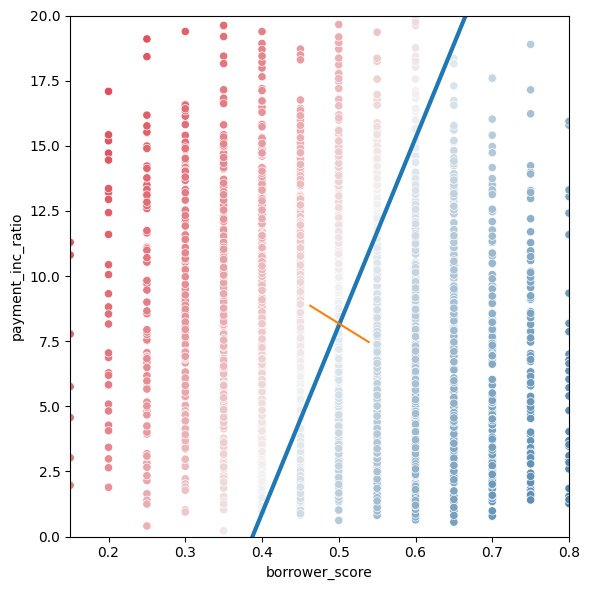

In [51]:

fig, ax = plt.subplots(figsize=(6, 6))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                    hue='default', data=lda_df, 
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

In [43]:
x_0

array([0.38754042])

In [44]:
x_20

array([0.6653493])